# Requirements

## Install required libraries

In [2]:
# !pip install hazm
# !pip install stopwords_guilannlp
# !pip install pandas
# !pip install tensorflow
# # !pip install keras

## Import Libraries

In [4]:
# General
import numpy as np
import pandas as pd
import codecs
# Keras
from keras import optimizers
from keras.models import Model, Sequential
from keras.layers import Dense, Input, Embedding, Dropout
from keras.layers import GlobalMaxPool1D, MaxPooling1D, GlobalMaxPooling1D
from keras.layers import LSTM, Bidirectional
from keras.layers import Conv1D
from keras.utils import plot_model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
# Preprocessing
from stopwords_guilannlp import stopwords_output
from hazm import *
# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
from keras.utils import plot_model
# Measuring metrics
from sklearn.metrics import f1_score

In [5]:
import tensorflow as tf
print(tf.__version__)


2.15.1



# Import & Analyze Dataset

In [7]:
test = pd.read_csv('./binary/Dataset/test.csv', index_col=None, header=None, encoding="utf-8")

In [8]:
x_test = test[0]
y_test = test[1]

In [9]:
print('Number of testing sentence: ', x_test.shape)
print('Number of testing label: ', y_test.shape)

Number of testing sentence:  (1854,)
Number of testing label:  (1854,)


In [10]:
binary_y_test = []
binary_x_test = []
for i, y in enumerate(y_test):
  if int(y) != 0:
    if int(y) > 0:
      binary_y_test.append(1)
      binary_x_test.append(x_test[i])
    else:
      binary_y_test.append(0)
      binary_x_test.append(x_test[i])

In [11]:
x_test = np.asarray(binary_x_test)
y_test = np.asarray(binary_y_test)


In [12]:
original = pd.read_csv('./Dataset/original.csv', index_col=None, header=None, encoding="utf-8")
balanced = pd.read_csv('./Dataset/balanced.csv', index_col=None, header=None, encoding="utf-8")
translation = pd.read_csv('./Dataset/translation.csv', index_col=None, header=None, encoding="utf-8")

In [13]:
selected_dataset = translation

In [14]:
selected_dataset = selected_dataset.sample(frac=1).reset_index(drop=True)

In [15]:
x_train = selected_dataset[0]
y_train = selected_dataset[1]

In [16]:
print('Number of training sentence: ', x_train.shape)
print('Number of training label: ', y_train.shape)

Number of training sentence:  (14046,)
Number of training label:  (14046,)


In [17]:
binary_y_train = []
binary_x_train = []
for i, y in enumerate(y_train):
  if int(y) != 0:
    if int(y) > 0:
      binary_y_train.append(1)
      binary_x_train.append(x_train[i])
    else:
      binary_y_train.append(0)
      binary_x_train.append(x_train[i])

In [18]:
# Convert dataframes to numpy arrays
x_train = np.asarray(binary_x_train)
y_train = np.asarray(binary_y_train)

In [19]:
# See the data number of sentence in each category
from collections import Counter
cnt = Counter(y_train)
cnt = dict(cnt)
print(cnt)

{1: 7856, 0: 2190}


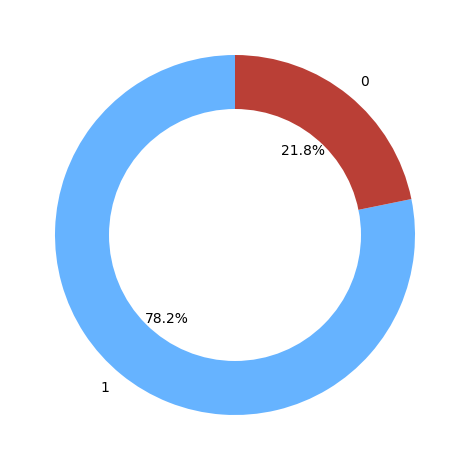

In [23]:
labels = list(cnt.keys())
sizes = list(cnt.values())
colors = ['#66b3ff', '#ba3f36','#ffcc99','#ff9999', '#a4a444']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

ax1.axis()
plt.tight_layout()

# plt.savefig('distribution.png')
plt.show()

# Preprocess

In [18]:
puncs = ['،', '.', ',', ':', ';', '"']
normalizer = Normalizer()
lemmatizer = Lemmatizer()

# turn a doc into clean tokens
def clean_doc(doc):
    doc = normalizer.normalize(doc) # Normalize document using Hazm Normalizer
    tokenized = word_tokenize(doc)  # Tokenize text
    tokens = []
    for t in tokenized:
      temp = t
      for p in puncs:
        temp = temp.replace(p, '')
      tokens.append(temp)
    # tokens = [w for w in tokens if not w in stop_set]    # Remove stop words
    tokens = [w for w in tokens if not len(w) <= 1]
    tokens = [w for w in tokens if not w.isdigit()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens] # Lemmatize sentence words
    tokens = ' '.join(tokens)
    return tokens

# Prepare data for Deep Learning model

## Apply preprocessing to data

In [19]:
# Apply preprocessing step to training data
train_docs = np.empty_like(x_train)
for index, document in enumerate(x_train):
  train_docs[index] = clean_doc(document)

In [20]:
# Applying preprocessing step to test data
test_docs = np.empty_like(x_test)
for index, document in enumerate(x_test):
  test_docs[index] = clean_doc(document)

## Setting tokenizer up

In [21]:
num_words = 2500

# Create the tokenizer
tokenizer = Tokenizer()

# fFt the tokenizer on the training documents
tokenizer.fit_on_texts(train_docs)

In [23]:
# Find maximum length of training sentences
max_length = max([len(s.split()) for s in train_docs])

## Embed sentences

In [24]:
# Embed training sequences
encoded_docs = tokenizer.texts_to_sequences(train_docs)

# Pad embeded training sequences
x_train_padded = pad_sequences(encoded_docs, maxlen=max_length, padding='post')

In [25]:
# Define vocabulary size (largest integer value)
vocab_size = len(tokenizer.word_index)

In [26]:
# Embed testing sequences
encoded_docs = tokenizer.texts_to_sequences(test_docs)
# Pad testing sequences
x_test_padded = pad_sequences(encoded_docs, maxlen=max_length, padding='post')

In [29]:
import pickle

# Save the tokenizer to file for later use in predicting sentiment of new text
with open('./tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

# Deep Learning Models

## B-LSTM Model

In [32]:
# the lstm structure for binary classification
model_blstm = Sequential()
model_blstm.add(Embedding(vocab_size+1, 300, input_length=max_length))
#model_blstm.add(Bidirectional(CuDNNLSTM(300, return_sequences=True, name='lstm_layer'))) # when using GPU
model_blstm.add(Bidirectional(LSTM(int(300/2), activation='tanh', return_sequences=True), merge_mode='concat')) # when using CPU
model_blstm.add(GlobalMaxPool1D())
model_blstm.add(Dropout(0.2))
model_blstm.add(Dense(500, activation="relu"))
model_blstm.add(Dropout(0.1))
model_blstm.add(Dense(1, activation='sigmoid'))

In [33]:
model_blstm.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_blstm.summary()
batch_size_blstm = 32
epochs_blstm = 3


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 254, 300)          2012100   
                                                                 


 bidirectional (Bidirection  (None, 254, 300)          541200    
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 300)               0         
 alMaxPooling1D)                                                 
                                                                 
 dropout (Dropout)           (None, 300)               0         
                                                                 
 dense (Dense)               (None, 500)               150500    
                                                                 
 dropout_1 (Dropout)         (None, 500)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 501       
                                                                 
Total params: 2704301 (10.32 MB)
Trainable params: 2704301 (10.32 MB)
Non-tr

In [34]:
# Train model
hist_blstm = model_blstm.fit(x_train_padded, y_train, batch_size=batch_size_blstm, epochs=epochs_blstm, shuffle=True, validation_data=(x_test_padded, y_test))

Epoch 1/3


314/314 [==============================] - 252s 783ms/step - loss: 0.3791 - accuracy: 0.8322 - val_loss: 0.2503 - val_accuracy: 0.8938
Epoch 2/3
314/314 [==============================] - 236s 753ms/step - loss: 0.2083 - accuracy: 0.9170 - val_loss: 0.2266 - val_accuracy: 0.9118
Epoch 3/3
314/314 [==============================] - 272s 866ms/step - loss: 0.1233 - accuracy: 0.9549 - val_loss: 0.2582 - val_accuracy: 0.9136


In [35]:
# Evaluate model
loss_blstm, acc_blstm = model_blstm.evaluate(x_test_padded, y_test, verbose=0)
print('Test Accuracy: %f' % (acc_blstm*100))

Test Accuracy: 91.359138


In [36]:
# Get prediction label
predict_x=model_blstm.predict(x_test_padded)
y_pred_blstm = (predict_x > 0.5).astype(int)


35/35 [==============================] - 6s 144ms/step


## CNN Model

In [39]:
# the CNN structure for binary classification
model_cnn = Sequential()
model_cnn.add(Embedding(vocab_size+1, 300, input_length=max_length))
model_cnn.add(Conv1D(filters=64, kernel_size=4, activation='relu', padding='same'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Conv1D(filters=64, kernel_size=8, activation='relu', padding='same'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Conv1D(filters=64, kernel_size=16, activation='relu', padding='same'))
model_cnn.add(GlobalMaxPooling1D())
model_cnn.add(Dropout(0.1))
model_cnn.add(Dense(100, activation="sigmoid"))
model_cnn.add(Dense(1, activation='sigmoid'))

In [40]:
model_cnn.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_cnn.summary()
batch_size_cnn = 64
epochs_cnn = 5

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 254, 300)          2012100   
                                                                 
 conv1d (Conv1D)             (None, 254, 64)           76864     
                                                                 
 max_pooling1d (MaxPooling1  (None, 127, 64)           0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 127, 64)           32832     
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 63, 64)            0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 63, 64)           

In [41]:
# Train model
hist_cnn = model_cnn.fit(x_train_padded, y_train, batch_size=batch_size_cnn, epochs=epochs_cnn, shuffle=True, validation_data=(x_test_padded, y_test))

Epoch 1/5


157/157 [==============================] - 18s 103ms/step - loss: 0.4121 - accuracy: 0.8154 - val_loss: 0.3033 - val_accuracy: 0.8506
Epoch 2/5
157/157 [==============================] - 17s 107ms/step - loss: 0.2231 - accuracy: 0.9107 - val_loss: 0.2302 - val_accuracy: 0.9136
Epoch 3/5
157/157 [==============================] - 16s 104ms/step - loss: 0.1317 - accuracy: 0.9541 - val_loss: 0.2243 - val_accuracy: 0.9244
Epoch 4/5
157/157 [==============================] - 17s 109ms/step - loss: 0.0803 - accuracy: 0.9733 - val_loss: 0.2488 - val_accuracy: 0.9235
Epoch 5/5
157/157 [==============================] - 17s 108ms/step - loss: 0.0479 - accuracy: 0.9868 - val_loss: 0.3438 - val_accuracy: 0.9100


In [42]:
# Evaluate model
loss_cnn, acc_cnn = model_cnn.evaluate(x_test_padded, y_test, verbose=0)
print('Test Accuracy: %f' % (acc_cnn*100))

Test Accuracy: 90.999103


In [43]:
# Get prediction label
predict_x_cnn = model_cnn.predict(x_test_padded)
y_pred_cnn=(predict_x_cnn > 0.5).astype(int)

35/35 [==============================] - 1s 14ms/step


# Confusion Matrix

In [44]:
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    print(im)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

class_names = np.array([0, 1])
np.set_printoptions(precision=2)

#### Create unique ID for each model

In [45]:
import uuid

id_blstm = uuid.uuid1().hex
id_cnn = uuid.uuid1().hex
model_path_blstm = f'./models/{id_blstm}_blstm_model_binary.h5'
model_path_cnn = f'./models/{id_cnn}_cnn_model_binary.h5'

#### create Confusion matrix

Confusion matrix, without normalization
[[148  48]
 [ 48 867]]
AxesImage(shape=(2, 2))
Normalized confusion matrix
[[0.76 0.24]
 [0.05 0.95]]
AxesImage(shape=(2, 2))


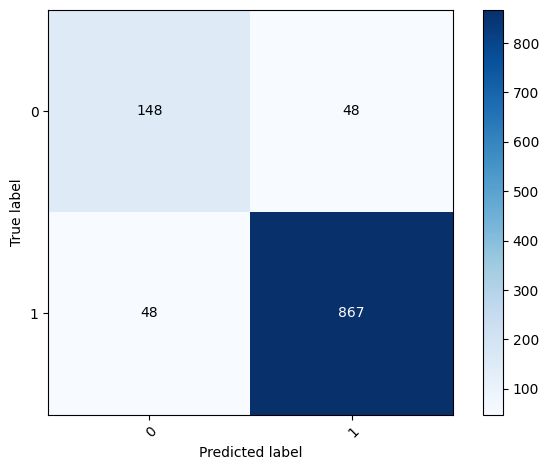

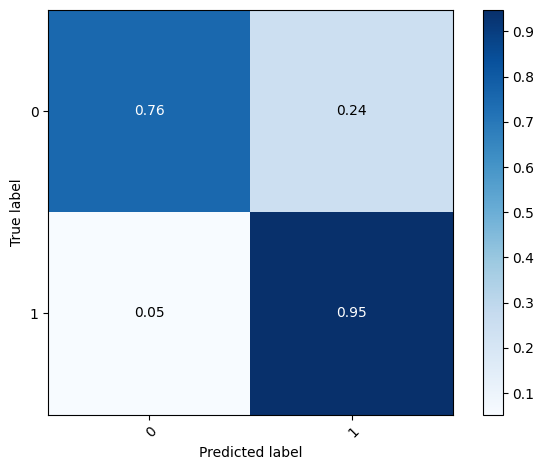

915


In [46]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(y_test, y_pred_blstm, classes=class_names)
# plt.savefig('cm-blstm.png')

# Plot normalized confusion matrix
plot_confusion_matrix(y_test, y_pred_blstm, classes=class_names, normalize=True)
plt.savefig(f'./plots/{id_blstm}_cm_blstm_normalized.jpg')
plt.show()

Confusion matrix, without normalization
[[153  43]
 [ 57 858]]
AxesImage(shape=(2, 2))
Normalized confusion matrix
[[0.78 0.22]
 [0.06 0.94]]
AxesImage(shape=(2, 2))


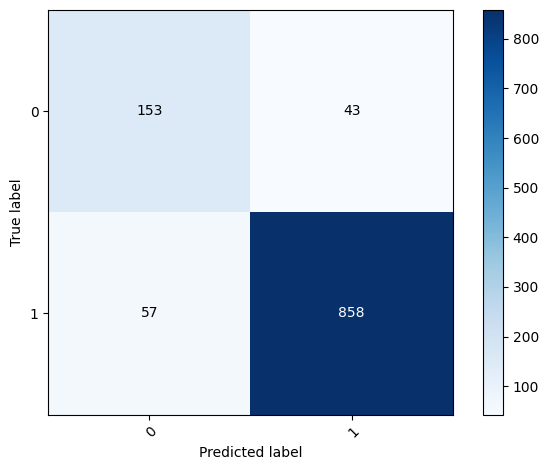

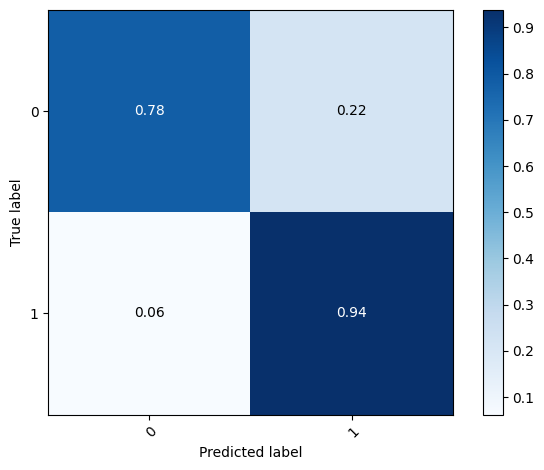

In [47]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(y_test, y_pred_cnn, classes=class_names)
# plt.savefig('cm-cnn.png')

# Plot normalized confusion matrix
plot_confusion_matrix(y_test, y_pred_cnn, classes=class_names, normalize=True)
plt.savefig(f'./plots/{id_cnn}_cm_cnn_normalized.jpg')
plt.show()

## F1 Score

#### BLSTM

In [48]:
print("(Weighted) F1 score of KerasEmb B-LSTM model:")
f1_score(y_test, y_pred_blstm, average='weighted')

(Weighted) F1 score of KerasEmb B-LSTM model:


0.9135913591359136

#### CNN

In [49]:
print("(Weighted) F1 score of KerasEmb CNN model:")
f1_score(y_test, y_pred_cnn, average='weighted')

(Weighted) F1 score of KerasEmb CNN model:


0.9111959274311148

# Model Visualization

In [50]:
# ! pip install pydot
# ! pip install pydotplus
# ! pip install graphviz

## Graphing Model Structure
#### BLSTM

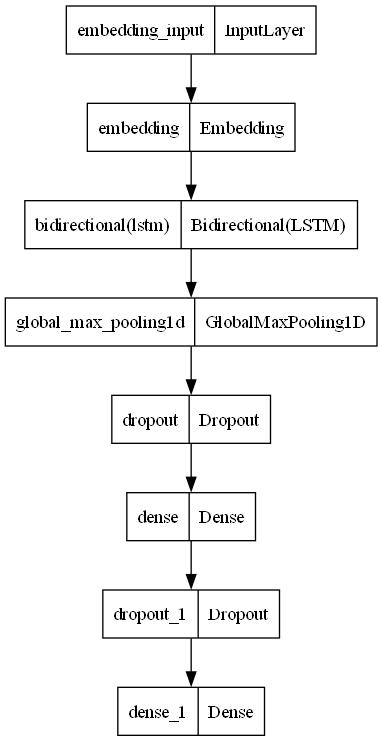

In [51]:
plot_model(model_blstm, to_file=f'./plots/{id_blstm}_model_graph_blstm.jpg')

#### CNN

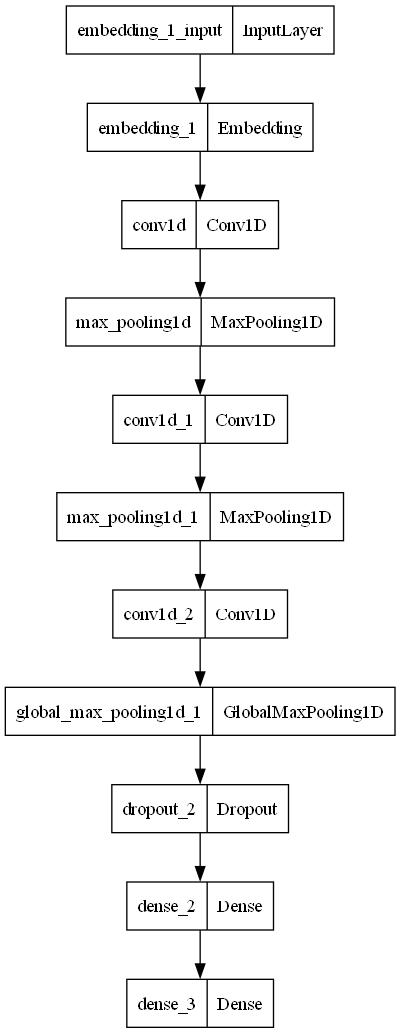

In [52]:

plot_model(model_cnn, to_file=f'./plots/{id_cnn}_model_graph_cnn.jpg')

### Saving Model and details

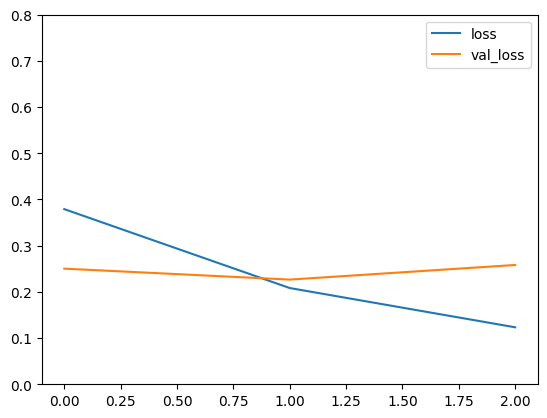

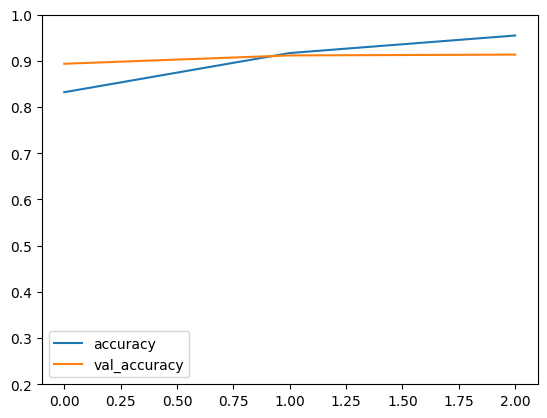

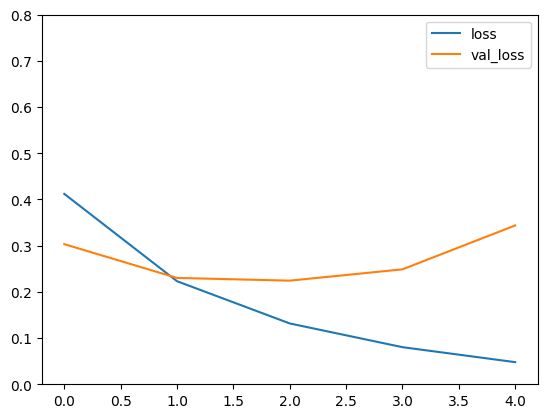

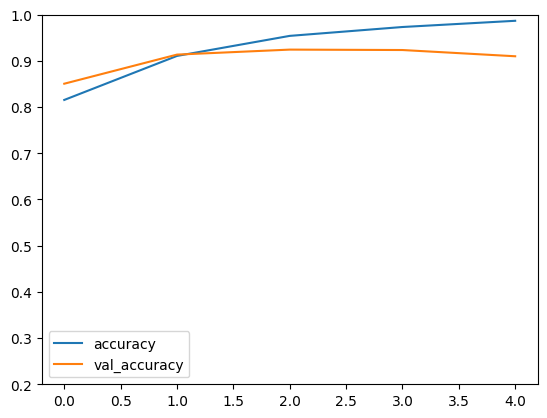

In [53]:

model_loss_blstm = pd.DataFrame(hist_blstm.history)
model_loss_cnn = pd.DataFrame(hist_cnn.history)
model_loss_blstm.head()

model_loss_blstm[['loss','val_loss']].plot(ylim=[0,0.8])
plt.savefig(f'./plots/{id_blstm}_blstm_loss.jpg')

model_loss_blstm[['accuracy','val_accuracy']].plot(ylim=[0.2,1])
plt.savefig(f'./plots/{id_blstm}_blstm_accuracy.jpg')

# CNN
print('CNN Model')

model_loss_cnn[['loss','val_loss']].plot(ylim=[0,0.8])
plt.savefig(f'./plots/{id_cnn}_cnn_loss.jpg')

model_loss_cnn[['accuracy','val_accuracy']].plot(ylim=[0.2,1])
plt.savefig(f'./plots/{id_cnn}_cnn_accuracy.jpg')

In [54]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from datetime import datetime

MeanSquaredError_blstm = mean_squared_error(predict_x, y_pred_blstm)
MeanSquaredError_cnn = mean_squared_error(predict_x_cnn, y_pred_cnn)

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

model_blstm.save(model_path_blstm)
model_cnn.save(model_path_cnn)

# Example true labels and predicted labels
predicted_labels = y_pred_blstm

# Calculate precision
precision_blstm = precision_score(y_test, y_pred_blstm)
precision_cnn = precision_score(y_test, y_pred_cnn)

# Calculate recall
recall_blstm = recall_score(y_test, y_pred_blstm)
recall_cnn = recall_score(y_test, y_pred_cnn)

# Calculate F-score
f_score_blstm = f1_score(y_test, y_pred_blstm)
f_score_cnn = f1_score(y_test, y_pred_cnn)

print("---BLSTM---")
print("Precision:", precision_blstm)
print("Recall:", recall_blstm)
print("F-score:", f_score_blstm)
print("Accuracy_score: ", accuracy_score(y_test, y_pred_blstm))

print("\n---CNN---")
print("Precision:", precision_cnn)
print("Recall:", recall_cnn)
print("F-score:", f_score_cnn)
print("Accuracy_score: ", accuracy_score(y_test, y_pred_cnn))

c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


---BLSTM---
Precision: 0.9475409836065574
Recall: 0.9475409836065574
F-score: 0.9475409836065574
Accuracy_score:  0.9135913591359136

---CNN---
Precision: 0.9522752497225305
Recall: 0.9377049180327869
F-score: 0.9449339207048458
Accuracy_score:  0.90999099909991


In [55]:
import csv
embedding = "keras"
# Append to CSV file
with open("./metrics_binary.csv", "a", newline="") as file:
    writer = csv.writer(file)
    # If the file is empty, write the header
    if file.tell() == 0:
        writer.writerow(["Id","Date", "Model","Model Path","Embedding", "epochs", "batch_size","vector dimentions",
                         "MeanSquaredError", "Precision", "Recall", "F-score"])
    writer.writerow([id_blstm, current_date,"BLSTM", model_path_blstm, embedding, epochs_blstm, batch_size_blstm, 300, MeanSquaredError_blstm, precision_blstm, recall_blstm, f_score_blstm])
    writer.writerow([id_cnn, current_date,"CNN", model_path_blstm, embedding, epochs_cnn, batch_size_cnn, 300, MeanSquaredError_cnn, precision_cnn, recall_cnn, f_score_cnn])

print("Metrics appended to CSV file.")

Metrics appended to CSV file.


## Prediction function

In [66]:
result_mapping= {0:"Bad",
                 1:"Good"}
def test_model(text):
    text = clean_doc(text)
    text = tokenizer.texts_to_sequences([text])
    text = pad_sequences(text, maxlen=max_length, padding='post')
    predict_text = model_cnn.predict(text)
    y_pred_blstm=int((predict_text>0.5))
    return result_mapping[y_pred_blstm]
print(test_model("مزخرف"))

1/1 [==============================] - 0s 60ms/step
Bad


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20296\1675846686.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_blstm=int((predict_text>0.5))
